# GEOS Mesh Viewer - Thesis Figures

Renders the mesh-and-geometry setup figures used in the thesis (Chapter 2):
the KGD single/parallel-fracture setups (`kgd_fracture_single.png`,
`kgd_fractures_all.png`) and the three-dimensional heterogeneous mesh
(`heterogeneous_base.png`), by parsing the deck XML `<Mesh>`/`<Geometry>` blocks
with `mesh_tools.py` and drawing 2D slices.

This is the trimmed thesis version; the full exploratory notebook (XML decoding
tests, interactive viewers, stress-field overlays) lives in
`research/GEOS/mesh_viewer.ipynb`.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import mesh_tools as mt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib import pyplot as plt

sns.set_theme(context="talk", style="whitegrid", palette="colorblind")

# Thesis Figures

In [3]:
import numpy as np
import mesh_tools as mt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib import pyplot as plt

sns.set_theme(context="paper", style="whitegrid", palette="colorblind")

In [4]:
import os
BASE_FIG_DIR = "../figures/"   # created on demand (relative to notebooks/)
os.makedirs(BASE_FIG_DIR, exist_ok=True)

## KGD mesh

In [5]:
mesh_str_kgd = """
  <Mesh>
    <!-- Sphinx_Mesh_InternalMesh -->
    <InternalMesh 
      name="mesh1"
      elementTypes="{C3D8}"
      xCoords="{ -100, 100 }"
      yCoords="{ 0, 50 }"
      zCoords="{ 0, 1 }"
      nx="{100 }"
      ny="{ 100 }"
      nz="{ 2 }"
      cellBlockNames="{cb1}"/>
    <!-- Sphinx_Mesh_InternalMesh_End -->
  </Mesh>
"""

geometery_str_kgd_single = """
  <Geometry>
    <Box
      name="fracture"
      xMin="{ -0.01, -0.01, -0.01 }"
      xMax="{ 0.01,  1.01,  1.01 }"/>
  </Geometry>
"""

geometery_str_kgd_multi = """
  <Geometry>
    <Box
      name="fracture1"
      xMin="{ val_1_neg, -0.01, -0.01 }"
      xMax="{ val_1_pos,  1.01,  1.01 }"/>

    
    <Box
      name="fracture2"
      xMin="{ val_2_neg, -0.01, -0.01 }"
      xMax="{ val_2_pos,  1.01,  1.01 }"/>

  </Geometry>
"""

In [6]:
mesh_param_kgd =  mt.parse_xml(mesh_str_kgd)
mesh_kgd = mt.GEOSMesh(**mesh_param_kgd[0])

mesh_kgd.name = "mesh"

In [7]:
geom_parm =  mt.parse_xml(geometery_str_kgd_single)
geom_parm[0]["name"] = "0 m"


kgd_fracs = {0: [mt.GEOSBox(**geom_parm[0])]}

for i in [8, 12, 16, 20, 24]:
    half_spacing = i / 2.0

    val_1_neg = -half_spacing - 0.01
    val_1_pos = -half_spacing + 0.01

    val_2_neg = half_spacing - 0.01
    val_2_pos = half_spacing + 0.01

    temp = geometery_str_kgd_multi.replace("val_1_neg", str(val_1_neg))
    temp = temp.replace("val_1_pos", str(val_1_pos))
    temp = temp.replace("val_2_neg", str(val_2_neg))
    temp = temp.replace("val_2_pos", str(val_2_pos))

    _geom_parm =  mt.parse_xml(temp)
    # _geom_parm[0]["name"] = f"fracture_{i}"
    # _geom_parm[1]["name"] = f"fracture_{i}"
    _geom_parm[0]["name"] = f"{i} m"
    _geom_parm[1]["name"] = f"{i} m"

    _box1 = mt.GEOSBox(**_geom_parm[0])
    _box2 = mt.GEOSBox(**_geom_parm[1])
    kgd_fracs[i] = [_box1, _box2]

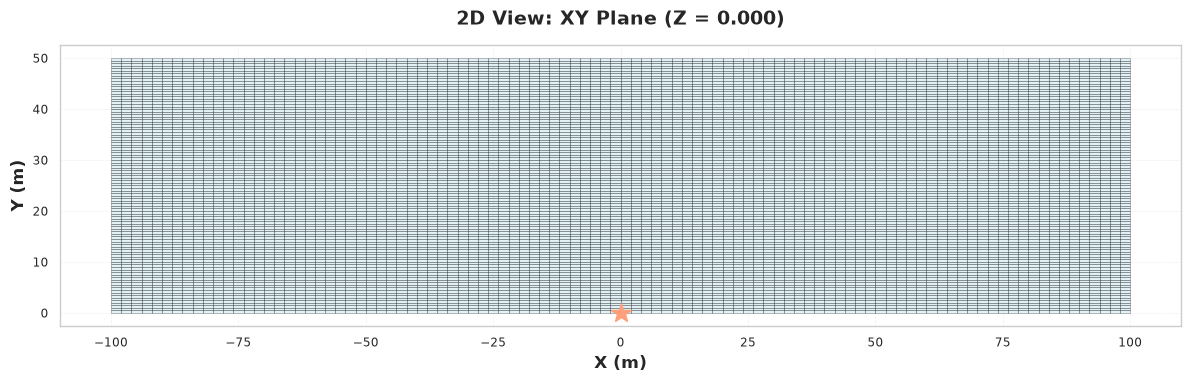

In [8]:
fig, ax = mt.plot_mesh_2d(
    mesh_kgd,
    boxes=kgd_fracs[0],
    plane="xy",
    position=0.0,
    face_color="lightblue",
    edge_color="black",
    edge_size=0.5,
    alpha=0.35,
    box_face_color="lightsalmon",
    box_edge_color="darkred",
    box_alpha=1.0,
    figsize=(12, 9),
    show_legend=False
)

ax.plot(0, 0, marker="*", color="lightsalmon", markersize=15)

fig.savefig(BASE_FIG_DIR + "kgd_fracture_single.png", dpi=300, bbox_inches="tight")

(0.0, 5.0)

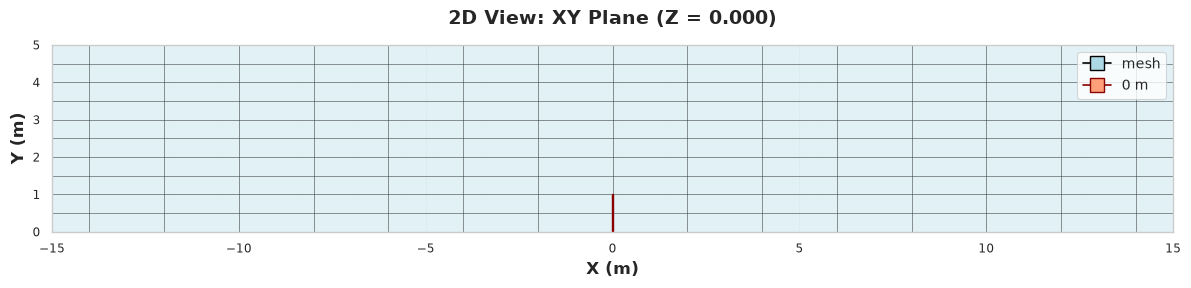

In [9]:
fig, ax = mt.plot_mesh_2d(
    mesh_kgd,
    boxes=kgd_fracs[0],
    plane="xy",
    position=0.0,
    face_color="lightblue",
    edge_color="black",
    edge_size=0.5,
    alpha=0.35,
    box_face_color="lightsalmon",
    box_edge_color="darkred",
    box_alpha=1.0,
    figsize=(12, 9)
)
ax.set_xlim(-15, 15)
ax.set_ylim(0, 5)

In [10]:
all_fracs = []
all_face_colors = []
all_edge_colors = []

cmap = plt.get_cmap("Dark2")

face_colors = [mcolors.to_hex(cmap(i / max(len(kgd_fracs) - 1, 1))) for i in range(len(kgd_fracs))]
for i, (k, v) in enumerate(kgd_fracs.items()):
    rgb = np.array(mcolors.to_rgb(face_colors[i]))
    darker = np.clip(rgb * 0.6, 0, 1)

    all_fracs.extend(v)
    all_face_colors.extend([face_colors[i]] * len(v))
    all_edge_colors.extend([mcolors.to_hex(darker)] * len(v))

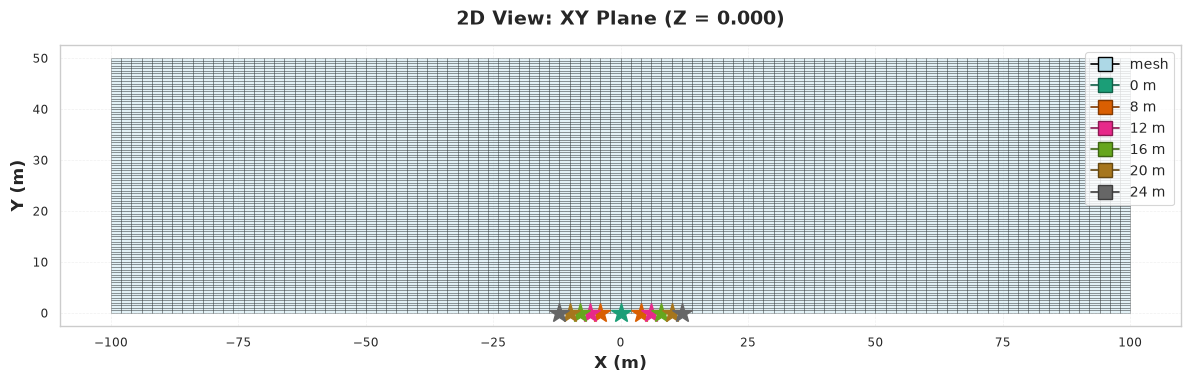

In [11]:
_keep_indicies = [0, 1, 3, 5, 7, 9]

fig, ax = mt.plot_mesh_2d(
    mesh_kgd,
    boxes=[all_fracs[i] for i in _keep_indicies],
    plane="xy",
    position=0.0,
    face_color="lightblue",
    edge_color="black",
    edge_size=0.5,
    alpha=0.35,
    box_face_color=[all_face_colors[i] for i in _keep_indicies],
    box_edge_color=[all_edge_colors[i] for i in _keep_indicies],
    box_alpha=1.0,
    figsize=(12, 9),
)

for frc, clr in zip(all_fracs, all_face_colors):
    x1, x2 = frc.xMin[0], frc.xMax[0]
    midpoint = (x1 + x2) / 2.0
    ax.plot(midpoint, 0, marker="*", color=clr, markersize=15)

fig.savefig(BASE_FIG_DIR + "kgd_fractures_all.png", dpi=300, bbox_inches="tight")

(0.0, 5.0)

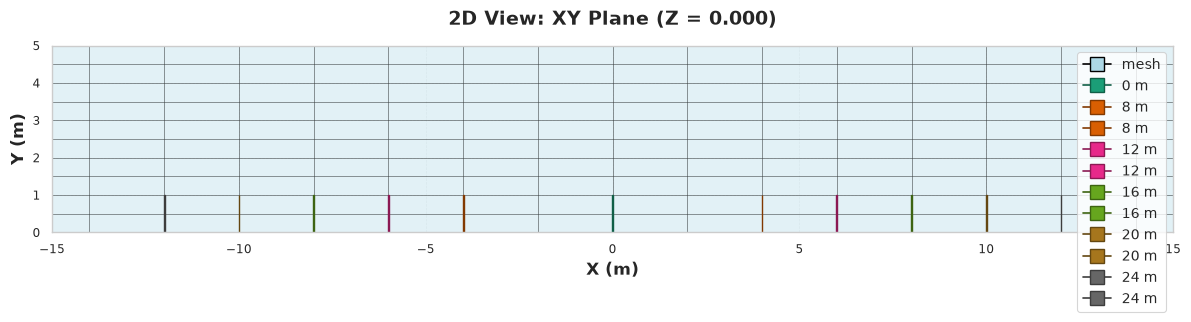

In [12]:
fig, ax = mt.plot_mesh_2d(
    mesh_kgd,
    boxes=all_fracs,
    plane="xy",
    position=0.0,
    face_color="lightblue",
    edge_color="black",
    edge_size=0.5,
    alpha=0.35,
    box_face_color=all_face_colors,
    box_edge_color=all_edge_colors,
    box_alpha=1.0,
    figsize=(12, 9),
)
ax.set_xlim(-15, 15)
ax.set_ylim(0, 5)

## Heterogeneous case

In [13]:
mesh_str_heterogeneousInSitu = """
  <Mesh>
    <InternalMesh
      name="mesh1"
      xCoords="{ 0, 200, 250 }"
      yCoords="{ -100, 0, 100 }"
      zCoords="{ -150, -100, 0, 100, 150 }"
      nx="{ 50, 5 }"
      ny="{ 10, 10 }"
      nz="{ 5, 25, 25, 5 }"
      xBias="{ 0, -0.6 }"
      yBias="{ 0.6, -0.6 }"
      zBias="{ 0.6, 0, 0, -0.6 }"
      cellBlockNames="{ cb1 }"
      elementTypes="{ C3D8 }"/>
  </Mesh>

"""

geometery_str_heterogeneousInSitu_base = """
  <Geometry>
    <Box
      name="source_a"
      xMin="{ -0.1, -0.1, -0.1 }"
      xMax="{ 4.1, 0.1, 4.1 }"/>

    <Box
      name="perf_a"
      xMin="{ -4.1, -0.1, -4.1 }"
      xMax="{ 4.1, 0.1, 4.1 }"/>

    <ThickPlane
      name="fracturable_a"
      normal="{ 0, 1, 0 }"
      origin="{ 0, 0, 0 }"
      thickness="0.1"/>
  </Geometry>
"""

In [14]:
mesh = mt.GEOSMesh(**mt.parse_xml(mesh_str_heterogeneousInSitu)[0])

In [15]:
geom_parm =  mt.parse_xml(geometery_str_heterogeneousInSitu_base)
box1 = mt.GEOSBox(**geom_parm[0])
box2 = mt.GEOSBox(**geom_parm[1])
box1, box2

(Box(name='source_a', xMin=[-0.1 -0.1 -0.1], xMax=[4.1 0.1 4.1]),
 Box(name='perf_a', xMin=[-4.1 -0.1 -4.1], xMax=[4.1 0.1 4.1]))

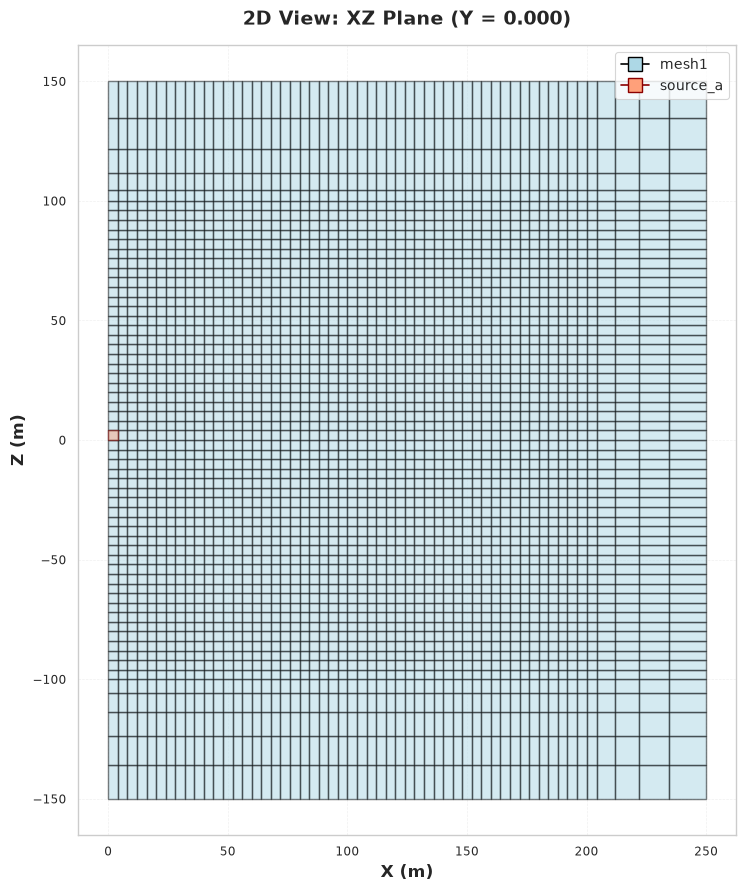

In [16]:
fig, ax = mt.plot_mesh_2d(
    mesh,
    boxes=[box1],
    plane="xz",
    position=0.0,
    face_color="lightblue",
    edge_color="black",
    alpha=0.30,
    box_face_color=["lightsalmon", "mediumpurple"],
    box_edge_color=["darkred", "indigo"],
    box_alpha=0.45,
    show_edges=True,
    figsize=(12, 9),
    show_legend=True,
)

fig.savefig(BASE_FIG_DIR + "heterogeneous_base.png", dpi=300, bbox_inches="tight")

## Heterogeneous case with the in-situ stress field as background

Reproduces the thesis figure `hetero_mesh_stress_syy.png`: the fracture-normal stress
$\sigma_{yy}$ ($\approx S_{h\min}$, since the fracture plane is $y=0$) painted behind
the mesh on the same XZ slice, side by side for the two property sets.  The benchmark
tables carry $\sim$6-9 MPa layering; the B6S-derived HFTS-2 tables carry 51-64 MPa
with the high-stress cap above $z \approx +40$ m that arrests upward growth in the
frac_22/23 runs.  Reuses `mesh` from the cell above.

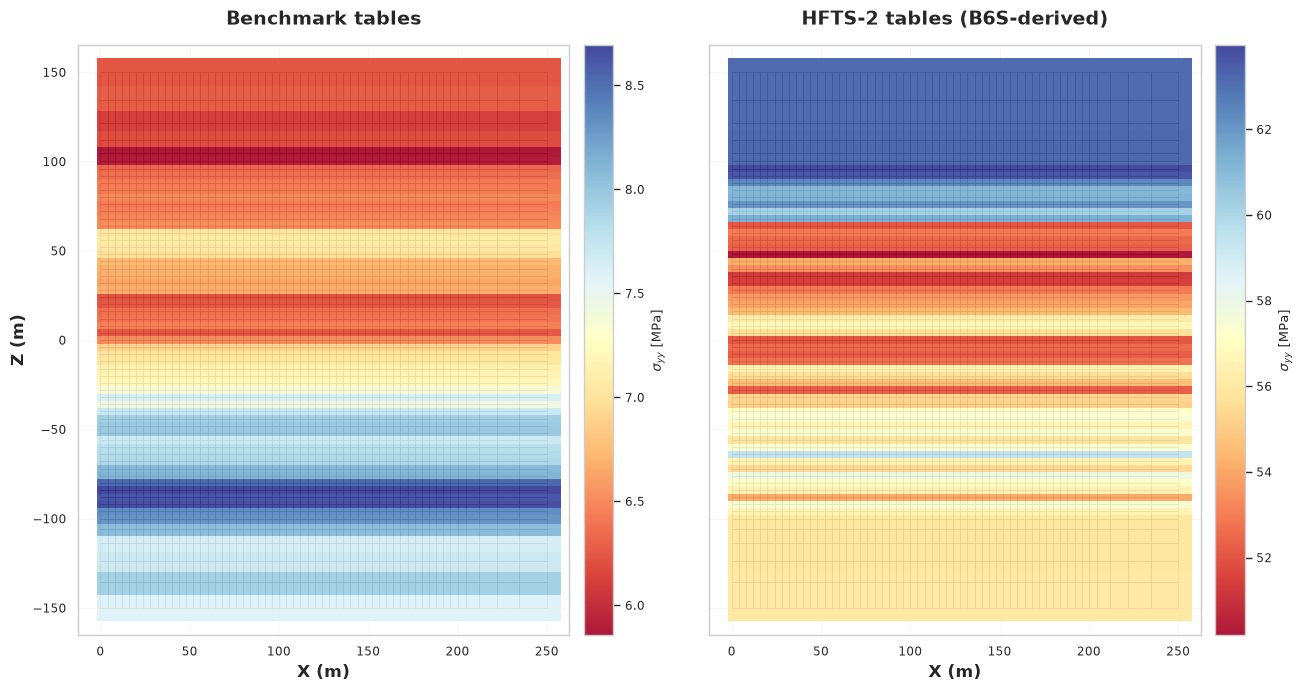

In [17]:
# GEOS TableFunction stress tables for the two property sets (x/y/z axes + sigma_* files)
XMLS = "../inputs/heterogeneous"   # packaged decks + tables/, tables_hfts2/
comp = {"sigma_xx": "sigma_xx.csv", "sigma_yy": "sigma_yy.csv", "sigma_zz": "sigma_zz.csv"}

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
for ax, (name, tdir) in zip(axes, (("Benchmark tables", f"{XMLS}/tables"),
                                   ("HFTS-2 tables (B6S-derived)", f"{XMLS}/tables_hfts2"))):
    st = mt.load_stress_tablefunction(base_dir=tdir, component_files=comp)   # reads axes + components, returns MPa
    # mesh slice first (edges only, no fill), drawn INTO the shared subplot via fig_prev/ax_prev
    mt.plot_mesh_2d(mesh, plane="xz", position=0.0, face_color="None",
                    edge_color="black", edge_size=0.4, alpha=0.5,
                    show_edges=True, title=name, fig_prev=fig, ax_prev=ax)
    # paint the stress component behind the mesh: cell-rendered, clipped at the 1-99th
    # percentiles so single extreme layers do not compress the color scale
    mt.add_stress_component_to_matplotlib_slice(ax, mesh, st, component="sigma_yy",
        plane="xz", position=0.0, method="upper", cmap="RdYlBu", alpha=0.9,
        render_mode="cell", clip_percentiles=(1.0, 99.0))
    leg = ax.get_legend()
    if leg: leg.remove()                    # the mesh legend adds nothing here
axes[1].set_ylabel("")                      # shared y-axis: label only on the left panel
fig.tight_layout()
fig.savefig(f"{BASE_FIG_DIR}hetero_mesh_stress_syy.png", dpi=300, bbox_inches="tight")
plt.show()